# Simon's algorithm

**Finite Abelian Hidden Subgroups Problems**

Simon's algorithm learns an unknown XOR symmetry of a function. Its quantum
part produces linear equations satisfied by that symmetry. Its classical part
solves those equations over the field $\mathbb{F}_2=\{0,1\}$.

This notebook develops the argument and implements both parts. Run the cells
from top to bottom. The code uses a local, ideal Qiskit simulator and needs no
cloud account. Familiarity with qubits, Hadamard gates, and binary linear
algebra is useful.

1. [The problem](#the-problem)
2. [Quantum section](#quantum-section)
3. [Classical section](#classical-section)
4. [Cost and interpretation](#cost-and-interpretation)

<a id="the-problem"></a>
## 1. The problem

Let $n\geq 1$. We have oracle access to a function
$f:\mathbb{F}_2^n\to\mathbb{F}_2^n$. There is an unknown string
$s\in\mathbb{F}_2^n$ such that, for every $x,x'\in\mathbb{F}_2^n$,

$$
f(x)=f(x')
\quad\Longleftrightarrow\quad
x'=x\ \text{or}\ x'=x\oplus s.
$$

Here $\oplus$ is coordinatewise addition modulo two. **The task is to find $s$.**

- If $s\neq 0$, each output value has exactly two preimages, $x$ and $x\oplus s$.
- If $s=0$, the function is one-to-one.

This is a promise about *all* collisions of $f$. Mere periodicity,
$f(x)=f(x\oplus s)$, would allow extra collisions and would not be sufficient.
The choice of $n$ output bits keeps the implementation simple. The same argument
works with another output length when the promise can be satisfied.

In the additive group $G=(\mathbb{Z}_2)^n$, the hidden subgroup is
$K=\{0,s\}$. For $s=0$ this is just $\{0\}$. The promise says that $f$ takes
one value on each coset of $K$ and different values on different cosets.

The quantum interface to $f$ is the reversible oracle

$$
U_f\lvert x\rangle\lvert z\rangle
=\lvert x\rangle\lvert z\oplus f(x)\rangle.
$$

It is reversible even when $f$ is two-to-one, because it retains $x$.
The solver is given $U_f$, not $s$ or a table of the function values.

<a id="quantum-section"></a>
## 2. Quantum section

### 2.1 Producing one equation

Start with an input register and an output register in
$\lvert 0^n\rangle\lvert 0^n\rangle$. Apply a Hadamard gate to every input
qubit and then query the oracle:

$$
\lvert 0^n\rangle\lvert 0^n\rangle
\ \longmapsto\
\frac{1}{\sqrt{2^n}}\sum_x\lvert x\rangle\lvert 0^n\rangle
\ \longmapsto\
\frac{1}{\sqrt{2^n}}\sum_x\lvert x\rangle\lvert f(x)\rangle.
$$

First suppose $s\neq 0$. If the output register were measured, an outcome
$f(x_0)$ would leave the input register in

$$
\frac{\lvert x_0\rangle+\lvert x_0\oplus s\rangle}{\sqrt{2}}.
$$

This measurement is useful for the derivation, but it is not required in the
circuit. Leaving the output register unmeasured gives the same input
measurement probabilities. We therefore apply the remaining gates only to
the input register and measure it at the end.

Define the binary inner product by

$$
x\cdot y=\left(\sum_{j=0}^{n-1}x_j y_j\right)\bmod 2.
$$

Since

$$
H^{\otimes n}\lvert x\rangle
=\frac{1}{\sqrt{2^n}}\sum_y(-1)^{x\cdot y}\lvert y\rangle,
$$

the second Hadamard layer sends the conditional input state to

$$
\frac{1}{\sqrt{2^{n+1}}}
\sum_y(-1)^{x_0\cdot y}\bigl(1+(-1)^{s\cdot y}\bigr)\lvert y\rangle.
$$

When $s\cdot y=1$, the two amplitudes cancel. When $s\cdot y=0$, they add.
Thus the measured string $y$ has distribution

$$
\Pr(Y=y)=
\begin{cases}
2^{-(n-1)}, & y\cdot s=0,\\
0, & y\cdot s=1.
\end{cases}
$$

Every run supplies an equation $y\cdot s=0$. It does not usually supply $s$
itself. The allowed outcomes form the $(n-1)$-dimensional subspace
$s^\perp=\{y:y\cdot s=0\}$.

If $s=0$, measuring the output would instead leave a single input basis state.
Its Hadamard transform has equal-magnitude amplitudes, so $Y$ is uniform over
all of $\mathbb{F}_2^n$. Both cases will be handled by the classical code.

### 2.2 Python environment and bit ordering

Install the packages in <code>requirements.txt</code> into your notebook
environment before running the imports. The optional cell below performs the
installation if its line is uncommented. Restart the kernel after installing.

We write strings as $x_{n-1}\cdots x_1x_0$, with $x_0$ on the right. Qiskit
qubit <code>x[0]</code> corresponds to that rightmost bit. Its measurement
strings use the same convention. The classical matrix keeps string characters
in their displayed, left-to-right order, so its columns are $n-1,\ldots,0$.
No reversal is needed when the measured strings become matrix rows.
See [Qiskit's bit-ordering guide](https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering).

In [1]:
# Optional setup for a new notebook environment.
# %pip install "qiskit==2.5.2" "numpy>=2,<3" "matplotlib>=3.9,<4" "pylatexenc>=2.10,<3"

In [2]:
import sys
from collections import Counter
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.primitives import StatevectorSampler

print("Python:", sys.version.split()[0])
for package in ("qiskit", "numpy", "matplotlib"):
    print(f"{package}: {version(package)}")

Python: 3.13.14
qiskit: 2.5.2
numpy: 2.5.3
matplotlib: 3.11.2


### 2.3 Constructing an oracle for local execution

To run the notebook, we need a circuit that satisfies the promise. The
following function is an **oracle factory**, not the recovery algorithm.
It receives a chosen string and builds $U_f$. Only this setup step knows $s$.

For nonzero $s$, choose a coordinate $p$ with $s_p=1$ and define

$$
f_s(x)=x\oplus x_p s.
$$

This is a linear map over $\mathbb{F}_2$. If $f_s(d)=0$, then
$d=d_p s$, so $d$ is either $0$ or $s$. Conversely, both choices map to zero.
Consequently,

$$
f_s(x)=f_s(x')
\quad\Longleftrightarrow\quad
f_s(x\oplus x')=0
\quad\Longleftrightarrow\quad
x\oplus x'\in\{0,s\}.
$$

For $s=0$, use $f_0(x)=x$. The circuit first XORs $x$ into the output, then
XORs $x_p s$ into it. Both operations use CNOT gates.

This linear family is convenient for testing. It is easy to learn classically
when its special form is known, so it is not a demonstration of the classical
query lower bound for arbitrary Simon oracles. The sampling and recovery
procedures below use only the oracle interface and apply to any function with
the stated promise.

In [3]:
def make_simon_oracle(secret):
    """Build an n-input, n-output XOR oracle for a chosen binary string."""
    if not isinstance(secret, str) or not secret or set(secret) - {"0", "1"}:
        raise ValueError("secret must be a nonempty binary string")

    n = len(secret)
    bits = [int(bit) for bit in reversed(secret)]  # Index by qubit number.
    oracle = QuantumCircuit(2 * n, name="U_f")

    for j in range(n):
        oracle.cx(j, n + j)  # z <- z XOR x

    if any(bits):
        pivot = bits.index(1)
        for j, bit in enumerate(bits):
            if bit:
                oracle.cx(pivot, n + j)  # z <- z XOR x_p s

    return oracle.to_gate(label="U_f")

### 2.4 Implementing the sampling circuit

The circuit below prepares the input superposition, applies one oracle query,
applies the second Hadamard layer, and measures the input into a classical
register named <code>y</code>. The output register starts in zero and is left
unmeasured.

<code>StatevectorSampler</code> supplies ideal measurement shots. We pass a
persistent random-number generator to it so that additional sampling calls
advance the random stream rather than restart it. The API is documented in the
[Qiskit StatevectorSampler reference](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler).

In [4]:
def simon_circuit(oracle, n):
    """Construct one sampling circuit without inspecting the oracle."""
    if n < 1 or oracle.num_qubits != 2 * n:
        raise ValueError("Expected an oracle with n input and n output qubits")

    x = QuantumRegister(n, "x")
    z = QuantumRegister(n, "z")
    y = ClassicalRegister(n, "y")
    circuit = QuantumCircuit(x, z, y)
    circuit.h(x)
    circuit.append(oracle, list(x) + list(z))
    circuit.h(x)
    circuit.measure(x, y)
    return circuit


def sample_simon(oracle, n, shots, sampler):
    """Return measured bitstrings in shot order."""
    if shots < 1:
        raise ValueError("shots must be positive")
    circuit = simon_circuit(oracle, n)
    result = sampler.run([circuit], shots=shots).result()[0]
    return result.data.y.get_bitstrings()

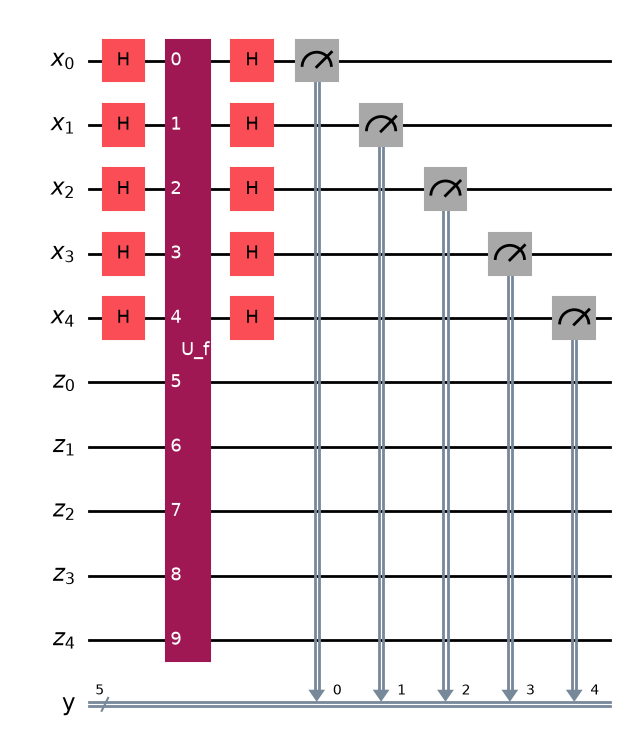

In [5]:
# This value constructs the oracle and later checks the result.
# The recovery functions never receive it.
secret_for_oracle = "10110"
n = len(secret_for_oracle)
oracle = make_simon_oracle(secret_for_oracle)
sampler = StatevectorSampler(seed=np.random.default_rng(2026))

figure = simon_circuit(oracle, n).draw(output="mpl", fold=-1)
display(figure)
plt.close(figure)

Collected 15 shots and 9 distinct outcomes
00110: 2
01000: 1
01001: 2
01111: 1
10010: 1
10100: 3
11010: 2
11100: 2
11101: 1


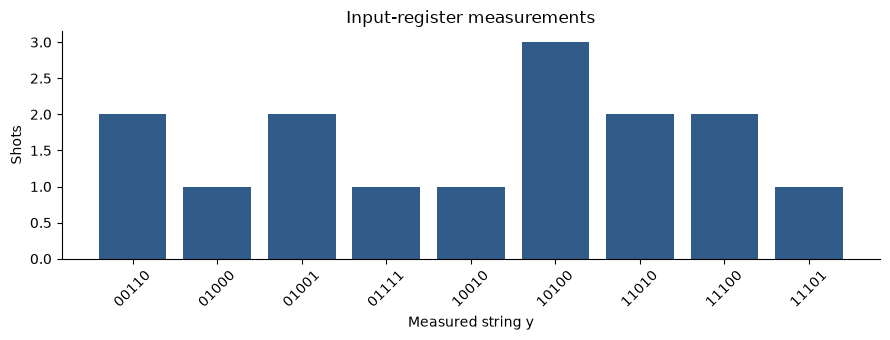

In [6]:
# n + 10 independent shots give a small theoretical rank-failure bound.
samples = sample_simon(oracle, n, shots=n + 10, sampler=sampler)
counts = Counter(samples)
print(f"Collected {len(samples)} shots and {len(counts)} distinct outcomes")
for outcome, count in sorted(counts.items()):
    print(f"{outcome}: {count}")

fig, ax = plt.subplots(figsize=(9, 3.5))
labels = sorted(counts)
ax.bar(labels, [counts[label] for label in labels], color="#315b88")
ax.set(xlabel="Measured string y", ylabel="Shots",
       title="Input-register measurements")
ax.tick_params(axis="x", labelrotation=45)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

The frequencies fluctuate because the number of shots is finite. A repeated
outcome repeats an equation. An all-zero outcome gives the equation $0=0$.
Neither necessarily increases the information available to the classical solver.

For the final decision between a nonzero candidate and $s=0$, we will sometimes
need ordinary function evaluations. They are available through the same oracle:
prepare $\lvert x\rangle\lvert0^n\rangle$, apply $U_f$, and read the output.
The following helper performs exactly this query. In an ideal simulation,
its result is deterministic, so one shot suffices.

In [7]:
def evaluate_oracle(oracle, n, input_string, sampler):
    """Evaluate f on a basis input using U_f, with no secret-string access."""
    if len(input_string) != n or set(input_string) - {"0", "1"}:
        raise ValueError("input_string must contain exactly n binary digits")
    if oracle.num_qubits != 2 * n:
        raise ValueError("Expected an oracle with 2n qubits")

    x = QuantumRegister(n, "x")
    z = QuantumRegister(n, "z")
    value = ClassicalRegister(n, "value")
    circuit = QuantumCircuit(x, z, value)
    for j, bit in enumerate(reversed(input_string)):
        if bit == "1":
            circuit.x(x[j])
    circuit.append(oracle, list(x) + list(z))
    circuit.measure(z, value)
    result = sampler.run([circuit], shots=1).result()[0]
    return result.data.value.get_bitstrings()[0]

<a id="classical-section"></a>
## 3. Classical section

### 3.1 Turning the samples into a linear system

Let $y^{(1)},\ldots,y^{(t)}$ be the measured strings. Put them into the rows
of a binary matrix $A$. Every row satisfies the same constraint on $s$:

$$
A s=0\quad\text{over }\mathbb{F}_2.
$$

If $s\neq0$, all rows lie in $s^\perp$, so $\operatorname{rank}(A)\leq n-1$.
Once the rank reaches $n-1$, the nullspace has dimension one and

$$
\ker A=\{0,s\}.
$$

The unique nonzero nullspace vector is then the answer. Counting distinct
samples is insufficient, because different rows can still be linearly
dependent. We must compute the rank over $\mathbb{F}_2$.

Gaussian elimination here uses row swaps and XOR of one row into another.
There is no floating-point division. After reducing $A$ to reduced row echelon
form $R$, choose each free column in turn, set that free variable to one, and
set the other free variables to zero. A pivot column $p_i$ obeys

$$
v_{p_i}=\bigoplus_{j\text{ free}}R_{ij}v_j.
$$

These choices produce a basis of $\ker A$. The function below returns the
reduced matrix, pivot columns, and nullspace basis. Its vectors retain the
left-to-right ordering of the measurement strings.

In [8]:
def nullspace_gf2(bitstrings, n):
    """Return (RREF, pivot columns, nullspace basis) using exact XOR arithmetic."""
    if n < 1:
        raise ValueError("n must be positive")
    bitstrings = list(bitstrings)
    if any(not isinstance(row, str) or len(row) != n or
           set(row) - {"0", "1"} for row in bitstrings):
        raise ValueError("Every sample must be an n-bit binary string")

    matrix = np.array([[int(bit) for bit in row] for row in bitstrings],
                      dtype=np.uint8).reshape(-1, n)
    reduced = matrix.copy()
    pivots = []
    pivot_row = 0

    for column in range(n):
        candidates = np.flatnonzero(reduced[pivot_row:, column])
        if candidates.size == 0:
            continue
        selected = pivot_row + int(candidates[0])
        reduced[[pivot_row, selected]] = reduced[[selected, pivot_row]]

        for row in range(len(reduced)):
            if row != pivot_row and reduced[row, column]:
                reduced[row] ^= reduced[pivot_row]

        pivots.append(column)
        pivot_row += 1

    free_columns = [column for column in range(n) if column not in pivots]
    basis = []
    for free_column in free_columns:
        vector = np.zeros(n, dtype=np.uint8)
        vector[free_column] = 1
        for row, pivot_column in enumerate(pivots):
            vector[pivot_column] = reduced[row, free_column]
        basis.append(vector)

    return reduced, pivots, basis


def as_bitstring(vector):
    return "".join(str(int(bit)) for bit in vector)

In [9]:
reduced, pivots, basis = nullspace_gf2(samples, n)
print("Rows are ordered as y[n-1], ..., y[0]")
print("Independent rows after reduction:")
print(reduced[:len(pivots)])
print("Rank:", len(pivots))
print("Nullspace basis:", [as_bitstring(vector) for vector in basis])

Rows are ordered as y[n-1], ..., y[0]
Independent rows after reduction:
[[1 0 0 1 0]
 [0 1 0 0 0]
 [0 0 1 1 0]
 [0 0 0 0 1]]
Rank: 4
Nullspace basis: ['10110']


### 3.2 Deciding when recovery is complete

The full promise includes $s=0$, so the solver uses three cases.

1. **Rank $n$.** The nullspace contains only zero, hence $s=0$.
2. **Rank $n-1$.** There is one nonzero candidate $v$. Compare $f(0)$ with
   $f(v)$. Equality proves $v=s$ by the promise. If they differ, $s=0$,
   since zero and $v$ are the only vectors left in the nullspace.
3. **Rank below $n-1$.** Several nonzero candidates remain. Collect more
   samples instead of choosing one arbitrarily.

Thus rank $n-1$ alone is sufficient when a nonzero secret is promised, but
the additional oracle check makes the code work for both cases. The callback
<code>evaluate_f</code> provides only ordinary function evaluations. No matrix
entries or gate definitions of $U_f$ are inspected.

In [10]:
def recover_simon(bitstrings, n, evaluate_f):
    """Recover s, or return None when the equations are still insufficient."""
    reduced, pivots, basis = nullspace_gf2(bitstrings, n)
    rank = len(pivots)

    if rank == n:
        return "0" * n, rank
    if rank < n - 1:
        return None, rank

    candidate = as_bitstring(basis[0])
    if evaluate_f("0" * n) == evaluate_f(candidate):
        return candidate, rank
    return "0" * n, rank

### 3.3 Recovering the string from the collected data

The next cell feeds the quantum samples into the classical solver. A bounded
retry loop requests further batches if the rank is too low. Reaching the
batch limit raises an explicit error rather than returning an unsupported
answer. Every retry adds equations to the same matrix.

In [11]:
evaluate_f = lambda x: evaluate_oracle(oracle, n, x, sampler)
recovered = None
for batch in range(5):
    recovered, rank = recover_simon(samples, n, evaluate_f)
    if recovered is not None:
        break
    print(f"Rank {rank} is below {n - 1}. Collecting another batch.")
    if batch < 4:
        samples.extend(sample_simon(oracle, n, shots=n + 10, sampler=sampler))

if recovered is None:
    raise RuntimeError("Insufficient rank after five batches. Run with more shots.")

print("Sampling shots used:", len(samples))
print("Rank:", rank)
print("Recovered string:", recovered)

# This comparison is an external check, after the solver has returned.
assert recovered == secret_for_oracle
print("The recovered string matches the oracle setup.")

Sampling shots used: 15
Rank: 4
Recovered string: 10110
The recovered string matches the oracle setup.


### 3.4 Checking the one-to-one and insufficient-data cases

For a one-to-one oracle the correct answer is zero. The same solver should
recover it without assuming in advance which case holds. With no samples and
$n\geq2$, it should instead report that more equations are needed.

In [12]:
zero_oracle = make_simon_oracle("0000")
zero_sampler = StatevectorSampler(seed=np.random.default_rng(17))
zero_samples = sample_simon(zero_oracle, 4, shots=24, sampler=zero_sampler)
zero_result, zero_rank = recover_simon(
    zero_samples, 4,
    lambda x: evaluate_oracle(zero_oracle, 4, x, zero_sampler),
)
assert zero_result == "0000"
print("One-to-one oracle:", zero_result, "with rank", zero_rank)


def no_evaluation_expected(_):
    raise AssertionError("Insufficient data should not trigger oracle evaluation")


pending, pending_rank = recover_simon([], 4, no_evaluation_expected)
assert pending is None and pending_rank == 0
print("No samples: more equations are needed.")

One-to-one oracle: 0000 with rank 4
No samples: more equations are needed.


<a id="cost-and-interpretation"></a>
## 4. Cost and interpretation

For nonzero $s$, let $d=n-1$. The samples are independent and uniform in the
$d$-dimensional space $s^\perp$. They fail to span it only if some nonzero
linear functional on that space vanishes on every sample. Each such
functional vanishes on a uniform sample with probability $1/2$. There are
$2^d-1$ nonzero functionals, so a union bound gives

$$
\Pr\bigl(\operatorname{rank}(A)<n-1\bigr)
\leq (2^{n-1}-1)2^{-t}<2^{n-1-t}.
$$

Consequently, $t=n-1+\lceil\log_2(1/\delta)\rceil$ shots suffice for
failure probability at most $\delta$, for $0<\delta<1$. For $s=0$, the
same argument on $\mathbb{F}_2^n$ bounds the probability of rank below $n$
by $(2^n-1)2^{-t}$. With $t=n+10$, that stronger full-rank criterion fails
with probability below $2^{-10}$.

Each sampling shot uses one call to $U_f$ and $2n$ Hadamard gates. If the
oracle implementation uses $C_f$ gates, the quantum sampling cost is
$O(t(C_f+n))$ gates. The final candidate check uses at most two further
ordinary oracle evaluations. The displayed elimination routine uses
$O(tn^2+n^2)$ binary operations and $O(tn+n^2)$ storage, including the
nullspace basis. For $t=O(n)$, these are $O(n^3)$ classical operations
and $O(n^2)$ storage.

The exponential quantum advantage concerns the **oracle query model for
general promised functions**. A classical collision search needs
$\Theta(2^{n/2})$ queries in the usual worst-case bounded-error setting,
whereas the quantum algorithm uses $O(n)$ queries for constant failure
probability. The local simulation does not inherit this speed advantage:
it stores a state vector for $2n$ qubits, requiring $O(2^{2n})$ amplitudes.
Keep the oracle width small when experimenting with this notebook.

The implementation assumes exact oracle behavior and noiseless samples.
Errors can produce equations that the true secret does not satisfy, so this
elimination procedure is not a noise-tolerant recovery method.

## References

- Daniel R. Simon, [On the Power of Quantum Computation](https://doi.org/10.1137/S0097539796298637),
  *SIAM Journal on Computing* 26(5), 1474–1483 (1997). Original algorithm and oracle separation.
- Andrew M. Childs and Wim van Dam,
  [Quantum algorithms for algebraic problems, Section IV.C](https://arxiv.org/abs/0812.0380).
  The finite abelian hidden subgroup framework.
- IBM Quantum Learning, [Simon's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/simon-algorithm).
  Further discussion of the promise and sampling distribution.
- Qiskit documentation:
  [StatevectorSampler](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler)
  and [bit ordering](https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering).